# Analys av studentdata

In [45]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## Läs in CSV-data

In [46]:
df = pd.read_csv('student_data.csv')
df.head()

,name,age,course,attendance,grade
0,David Andersson,18,Matematik,100.0,E
1,David Andersson,18,Svenska,89.5,F
2,David Andersson,18,Engelska,100.0,C
3,David Andersson,18,Historia,94.3,D
4,David Andersson,18,Programmering,100.0,C


## Närvaro - medel, median och standardavvikelse

In [47]:
print(df["attendance"].mean())
print(df["attendance"].median())
print(df["attendance"].std())

87.7716
88.6
9.49284053816169


## Betyg till numeriskt värde

In [48]:
grade_map = {
    "A": 5,
    "B": 4,
    "C": 3,
    "D": 2,
    "E": 1,
    "F": 0
}

df["grade_num"] = df["grade"].map(grade_map)

## Snittbetyg i de olika kurserna

In [49]:
# Gruppera efter kurs och beräkna medelvärdet för betyg
avg_grade_by_course = df.groupby("course")["grade_num"].mean().sort_values(ascending=False)
print(avg_grade_by_course)
print(f"\nKursen med bäst betyg: {avg_grade_by_course.idxmax()} (medel: {avg_grade_by_course.max():.2f})")

course
Historia         2.75
Svenska          2.50
Programmering    2.49
Engelska         2.45
Matematik        2.27
Name: grade_num, dtype: float64

Kursen med bäst betyg: Historia (medel: 2.75)


## Närvaro i de olika kurserna

In [50]:
avg_attendance_by_course = df.groupby("course")["attendance"].mean().sort_values(ascending=False)
print(avg_attendance_by_course)

course
Engelska         88.196
Matematik        87.986
Historia         87.662
Svenska          87.566
Programmering    87.448
Name: attendance, dtype: float64


## Elever med problematisk frånvaro

In [51]:
attendance_by_student = df.groupby("name")["attendance"].mean().sort_values()
attendance_by_student.head(10)

name
Evelina Karlsson    64.34
David Persson       66.48
Anna Johansson      71.96
Pelle Nilsson       73.14
Sara Eriksson       73.50
Vera Karlsson       73.82
Hugo Andersson      74.14
Pelle Karlsson      74.16
Noah Gustafsson     75.52
Klara Olsson        76.60
Name: attendance, dtype: float64

## Korrelation mellan närvaro och betyg

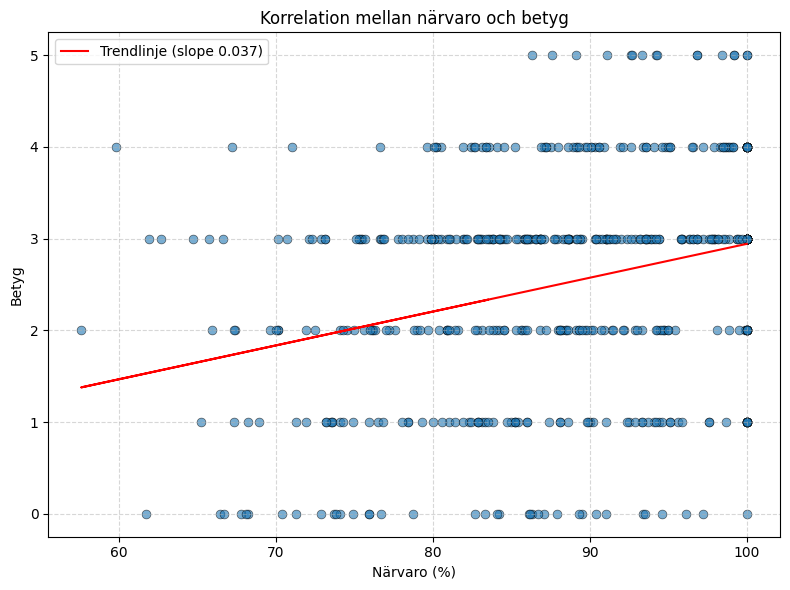

In [52]:
x = df["attendance"]
y = df["grade_num"]

# trendlinje
m, b = np.polyfit(x, y, 1)

plt.figure(figsize=(8, 6))
plt.scatter(x, y, alpha=0.6, s=40, edgecolors="k", linewidths=0.5)

# trendlinje
plt.plot(x, m * x + b, color="red", label=f"Trendlinje (slope {m:.3f})")

plt.xlabel("Närvaro (%)")
plt.ylabel("Betyg")
plt.title("Korrelation mellan närvaro och betyg")
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()

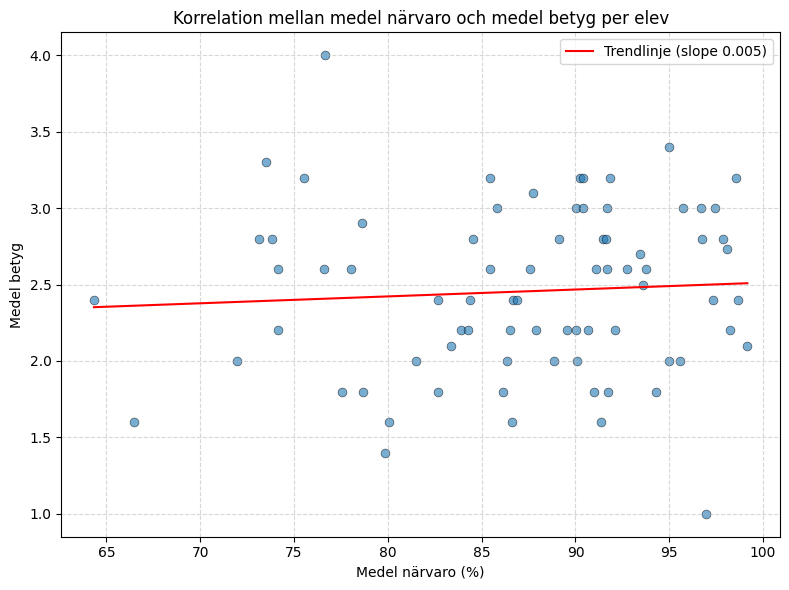

In [53]:
# Beräkna medelvärde för betyg per elev
grade_by_student = df.groupby("name")["grade_num"].mean()

# Scatterplot för medelvärden per elev
x_student = attendance_by_student
y_student = grade_by_student

# Trendlinje
m_student, b_student = np.polyfit(x_student, y_student, 1)

plt.figure(figsize=(8, 6))
plt.scatter(x_student, y_student, alpha=0.6, s=40, edgecolors="k", linewidths=0.5)

# Trendlinje
plt.plot(x_student, m_student * x_student + b_student, color="red", label=f"Trendlinje (slope {m_student:.3f})")

plt.xlabel("Medel närvaro (%)")
plt.ylabel("Medel betyg")
plt.title("Korrelation mellan medel närvaro och medel betyg per elev")
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()